# Wholesale Customer Segmentation with Singular Value Decomposition

This notebook walks through **truncated singular value decomposition (SVD)** on the **Wholesale Customers** dataset. Each customer is represented by annual spending across six product categories, and SVD finds low-dimensional spending patterns that summarize the matrix.

The first code cell imports libraries and sets plot defaults. **Notebook outline:**

1. Load data and basic quality checks  
2. Exploratory analysis with spending plots  
3. Center and scale the spending matrix  
4. Fit SVD from `rice_ml`  
5. Explained variance and reconstruction error  
6. Matrix reconstruction visualizations  
7. Latent-space and loading visualizations  
8. Discussion and limitations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

from rice_ml.processing.datasets import find_data_file
from rice_ml.processing.pre_processing import StandardScaler
from rice_ml.unsupervised_learning.svd import SVD

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4.5)

## 1. Load data and quality checks

We read `Wholesale_customers_data.csv` via `find_data_file` so the notebook runs from the repo root, from this folder, or from Jupyter with any working directory.

In [2]:
df = pd.read_csv(find_data_file("Wholesale_customers_data.csv"))

spend_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
X = df[spend_cols].to_numpy(dtype=float)

print("Shape:", df.shape)
print("Channel counts:")
print(df["Channel"].value_counts().sort_index())
print("\nRegion counts:")
print(df["Region"].value_counts().sort_index())

df.head()

Shape: (440, 8)
Channel counts:
Channel
1    298
2    142
Name: count, dtype: int64

Region counts:
Region
1     77
2     47
3    316
Name: count, dtype: int64


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 2. Exploratory analysis

Wholesale spending is highly skewed: a few customers spend much more than the rest in some categories. The plots below use `log1p` spending for readability while preserving zeros.

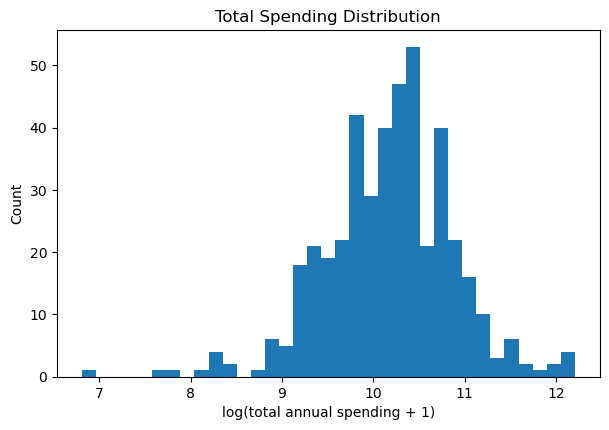

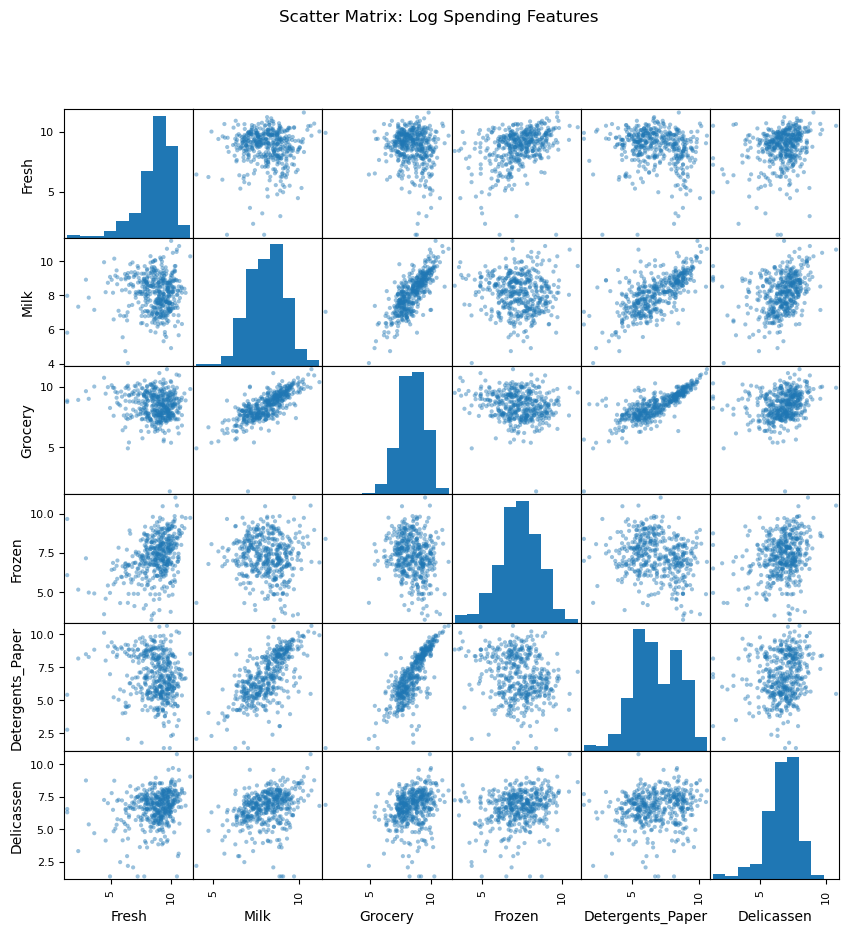

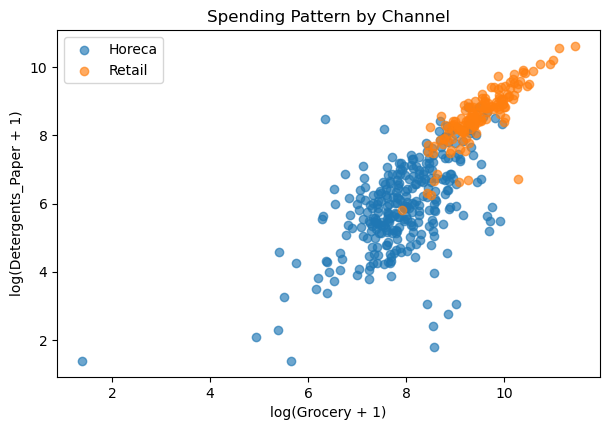

/var/folders/37/vd2xcb9d7v15dw6bcznn2ym80000gn/T/ipykernel_45992/2415451084.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([log_df[f] for f in spend_cols], labels=spend_cols)


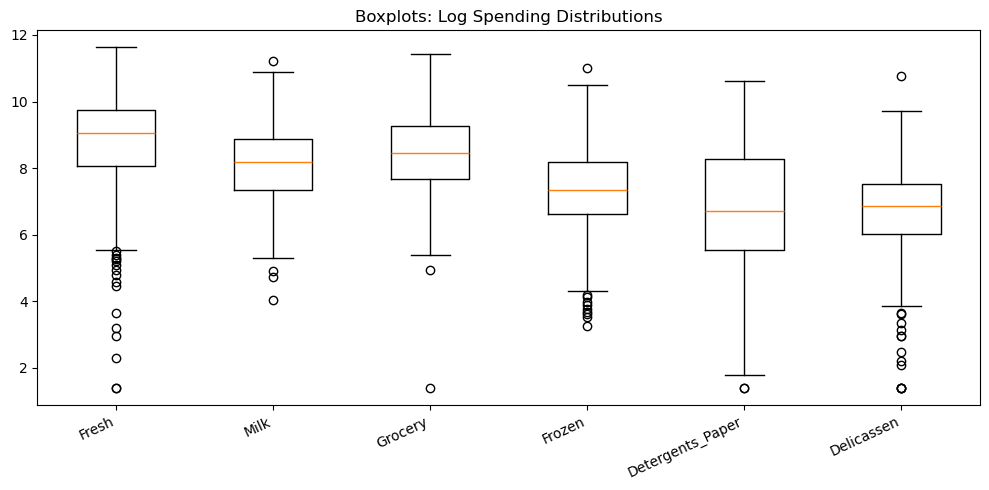

In [3]:
log_df = df.copy()
log_df[spend_cols] = np.log1p(log_df[spend_cols])

# Total spending distribution.
total_spend = df[spend_cols].sum(axis=1)
plt.figure()
plt.hist(np.log1p(total_spend), bins=35)
plt.xlabel("log(total annual spending + 1)")
plt.ylabel("Count")
plt.title("Total Spending Distribution")
plt.show()

# Scatter matrix for log spending features.
scatter_matrix(log_df[spend_cols], figsize=(10, 10), diagonal="hist", alpha=0.45)
plt.suptitle("Scatter Matrix: Log Spending Features")
plt.show()

# Two-category view colored by channel.
for channel, label, color in [(1, "Horeca", "tab:blue"), (2, "Retail", "tab:orange")]:
    mask = df["Channel"] == channel
    plt.scatter(
        np.log1p(df.loc[mask, "Grocery"]),
        np.log1p(df.loc[mask, "Detergents_Paper"]),
        label=label,
        alpha=0.65,
        color=color,
    )
plt.xlabel("log(Grocery + 1)")
plt.ylabel("log(Detergents_Paper + 1)")
plt.title("Spending Pattern by Channel")
plt.legend()
plt.show()

# Boxplots for log spending distributions.
plt.figure(figsize=(10, 5))
plt.boxplot([log_df[f] for f in spend_cols], labels=spend_cols)
plt.xticks(rotation=25, ha="right")
plt.title("Boxplots: Log Spending Distributions")
plt.tight_layout()
plt.show()

## 3. Center and scale the spending matrix

`rice_ml.SVD` factorizes the matrix it receives directly. Here we use `StandardScaler` so each spending category contributes on a comparable scale before factorization.

In [4]:
scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)

print("Scaled matrix shape:", Xs.shape)
print("Scaled column means:", Xs.mean(axis=0).round(4))
print("Scaled column stds:", Xs.std(axis=0).round(4))

Scaled matrix shape: (440, 6)
Scaled column means: [-0.  0. -0.  0.  0. -0.]
Scaled column stds: [1. 1. 1. 1. 1. 1.]


## 4. Fit SVD

The model below uses the project implementation in `src/rice_ml/unsupervised_learning/svd.py`. Truncated SVD factorizes the scaled matrix as $X \approx U_k \Sigma_k V_k^\top$.

In [5]:
svd = SVD(n_components=6).fit(Xs)
Z = svd.transform(Xs)

print(f"latent shape: {Z.shape}")
print(f"singular values: {svd.singular_values_.round(2)}")

latent shape: (440, 6)
singular values: [34.11 27.37 18.05 15.75 11.21  5.26]


## 5. Explained variance and reconstruction error

The singular values show how much matrix energy each component captures. Reconstruction error decreases as more components are kept.

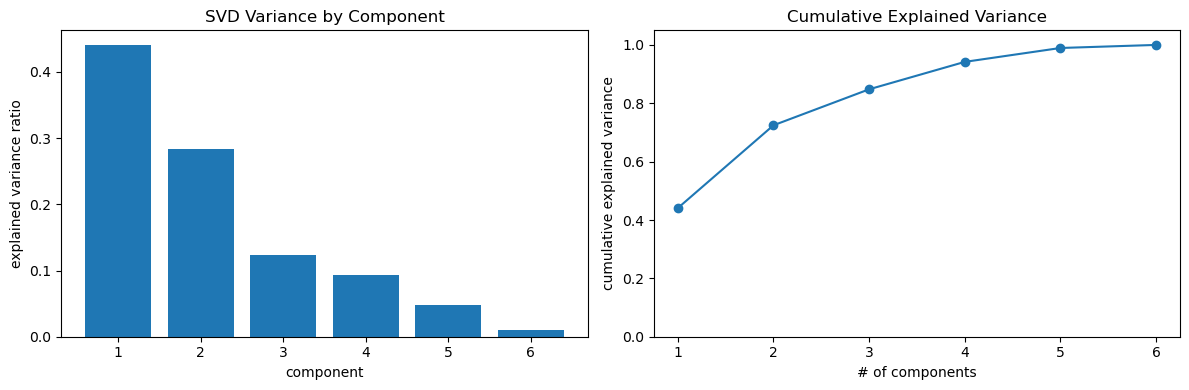

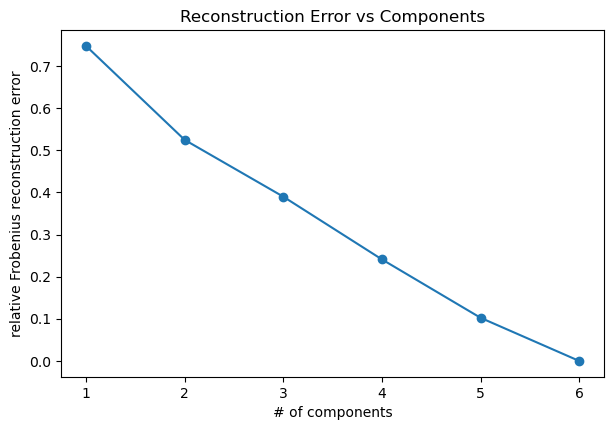

In [6]:
components = np.arange(1, len(svd.singular_values_) + 1)
cum = np.cumsum(svd.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(components, svd.explained_variance_ratio_)
axes[0].set_xlabel("component")
axes[0].set_ylabel("explained variance ratio")
axes[0].set_title("SVD Variance by Component")

axes[1].plot(components, cum, marker="o")
axes[1].set_xlabel("# of components")
axes[1].set_ylabel("cumulative explained variance")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

errors = []
for k in components:
    model_k = SVD(n_components=int(k)).fit(Xs)
    X_recon = model_k.inverse_transform(model_k.transform(Xs))
    rel_error = np.linalg.norm(Xs - X_recon, ord="fro") / np.linalg.norm(Xs, ord="fro")
    errors.append(rel_error)

plt.figure()
plt.plot(components, errors, marker="o")
plt.xlabel("# of components")
plt.ylabel("relative Frobenius reconstruction error")
plt.title("Reconstruction Error vs Components")
plt.show()

## 6. Matrix reconstruction visualizations

The heatmaps compare the scaled spending matrix, a rank-2 SVD reconstruction, and the remaining residual. The transpose makes rows correspond to spending categories and columns correspond to customers.

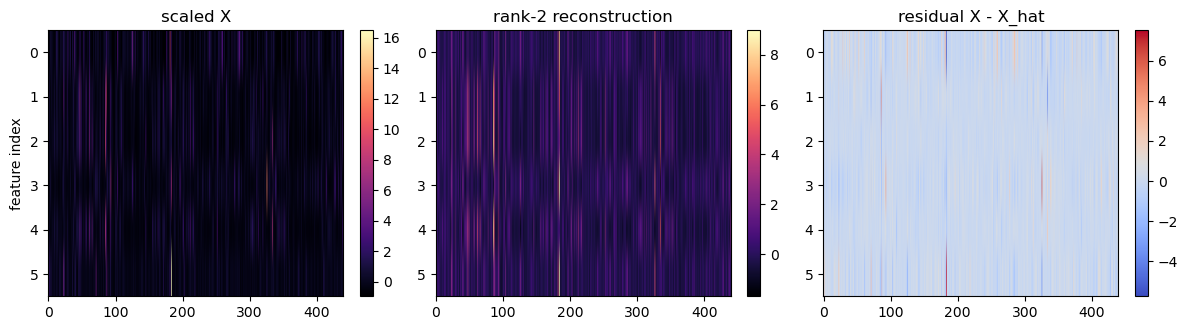

In [7]:
svd2 = SVD(n_components=2).fit(Xs)
Z2 = svd2.transform(Xs)
approx2 = svd2.inverse_transform(Z2)
residual = Xs - approx2

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
im0 = axes[0].imshow(Xs.T, aspect="auto", cmap="magma")
axes[0].set_title("scaled X")
axes[0].set_ylabel("feature index")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(approx2.T, aspect="auto", cmap="magma")
axes[1].set_title("rank-2 reconstruction")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(residual.T, aspect="auto", cmap="coolwarm")
axes[2].set_title("residual X - X_hat")
plt.colorbar(im2, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()

## 7. Latent-space and loading visualizations

The first two SVD coordinates give a compact map of customers. The loading plot shows which spending categories contribute most strongly to the first two components.

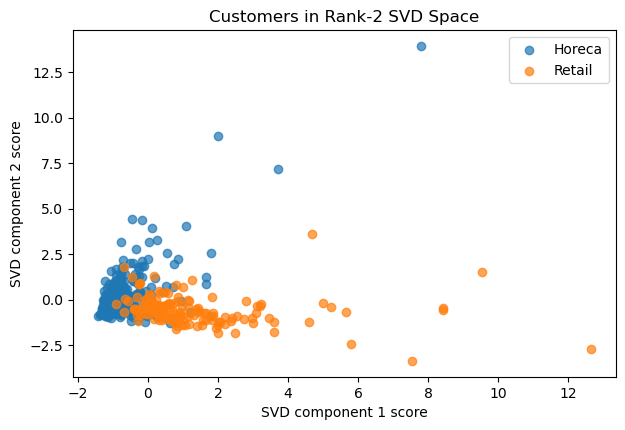

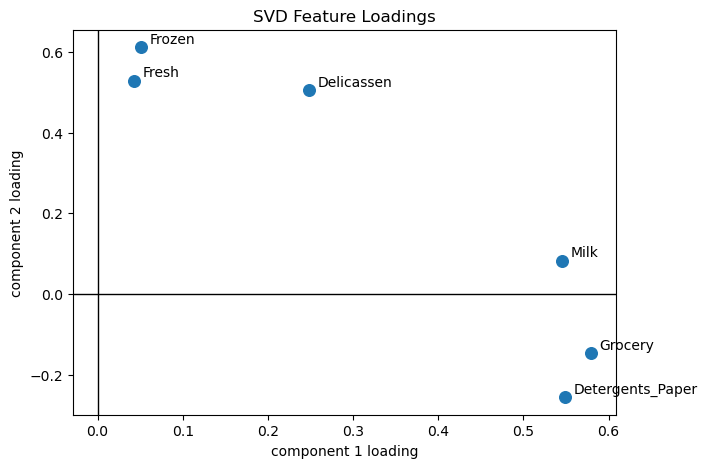

,component 1,component 2
Fresh,0.0429,0.5279
Milk,0.5451,0.0832
Grocery,0.5793,-0.1461
Frozen,0.0512,0.6113
Detergents_Paper,0.5486,-0.2552
Delicassen,0.2487,0.5042


In [8]:
# Latent customer map colored by channel.
plt.figure()
for channel, label, color in [(1, "Horeca", "tab:blue"), (2, "Retail", "tab:orange")]:
    mask = df["Channel"] == channel
    plt.scatter(Z2[mask, 0], Z2[mask, 1], label=label, alpha=0.7, color=color)
plt.xlabel("SVD component 1 score")
plt.ylabel("SVD component 2 score")
plt.title("Customers in Rank-2 SVD Space")
plt.legend()
plt.show()

# Component loadings.
loadings = pd.DataFrame(
    svd2.components_.T,
    index=spend_cols,
    columns=["component 1", "component 2"],
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(loadings["component 1"], loadings["component 2"], s=70)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)
for name, row in loadings.iterrows():
    ax.text(row["component 1"] + 0.01, row["component 2"] + 0.01, name)
ax.set_xlabel("component 1 loading")
ax.set_ylabel("component 2 loading")
ax.set_title("SVD Feature Loadings")
plt.show()

loadings.round(4)

## 8. Discussion

**Low-rank structure.** The printed summary below is generated from the actual run so it stays consistent with the plots.

**Scaling.** Because SVD directly factorizes the input matrix, preprocessing changes the meaning of the components. Scaling makes the six spending categories comparable before extracting low-rank structure.

**Explained variance.** A steep cumulative curve means the first few singular directions capture most of the matrix energy. A flatter curve means the spending patterns require more components.

**Latent space.** The rank-2 customer map can reveal channel structure or unusual customers, but SVD itself is unsupervised: `Channel` is used only for coloring the plot, not for fitting.

**Limitations.** SVD is linear and sensitive to scaling and outliers. For heavily skewed spending data, log transforms, robust scaling, clustering, or PCA-style centering choices may change the interpretation.

In [9]:
print("--- Auto-generated results summary ---")
print(f"Singular values: {svd.singular_values_.round(2)}")
print(f"Cumulative explained variance after 2 components: {cum[1]:.4f}")
print(f"Rank-2 relative reconstruction error: {errors[1]:.4f}")
print("Top absolute loadings by component:")
print(loadings.abs().sort_values("component 1", ascending=False).round(4))

--- Auto-generated results summary ---
Singular values: [34.11 27.37 18.05 15.75 11.21  5.26]
Cumulative explained variance after 2 components: 0.7246
Rank-2 relative reconstruction error: 0.5248
Top absolute loadings by component:
                  component 1  component 2
Grocery                0.5793       0.1461
Detergents_Paper       0.5486       0.2552
Milk                   0.5451       0.0832
Delicassen             0.2487       0.5042
Frozen                 0.0512       0.6113
Fresh                  0.0429       0.5279
